In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
from utils import RAT

In [9]:
RAT_ID = 2  
LIGHTING = "light"  
rat = RAT(n=RAT_ID, lighting=LIGHTING, filter_speed=False , t_max=None)
t = rat.T # (s), starts at 0  

x = rat.X # (cm)  

y = rat.Y # (cm)  

v = rat.V # (cm/s)  

spikes_by_cell = {}  

spikes_by_cell.update(rat.grid_mod1)  

spikes_by_cell.update(rat.grid_mod2)  

spikes_by_cell.update(rat.grid_mod3)    

In [11]:

# ==========================================
# 1. Parameters and Data Preparation
# ==========================================
delta_t = 0.1  # Time bin size in seconds (100 ms is standard)
spatial_bin_size = 5.0  # cm
disp_bin_size = 2.0     # cm (displacement bins)

# Create time bins
time_bins = np.arange(t[0], t[-1], delta_t)
n_bins = len(time_bins) - 1

# Interpolate X and Y to match the centers of the time bins
t_centers = time_bins[:-1] + delta_t / 2
x_binned = np.interp(t_centers, t, x)
y_binned = np.interp(t_centers, t, y)

# Calculate true displacement per delta_t
dx_binned = np.diff(x_binned, prepend=x_binned[0])
dy_binned = np.diff(y_binned, prepend=y_binned[0])

# Bin spikes for each cell
cell_ids = list(spikes_by_cell.keys())
n_cells = len(cell_ids)
spike_counts = np.zeros((n_bins, n_cells))

for i, c_id in enumerate(cell_ids):
    spikes = spikes_by_cell[c_id]
    counts, _ = np.histogram(spikes, bins=time_bins)
    spike_counts[:, i] = counts

# Split into Training (80%) and Testing (20%) sets
split_idx = int(n_bins * 0.8)
train_spikes = spike_counts[:split_idx, :]
test_spikes = spike_counts[split_idx:, :]

# ==========================================
# 2. Build Tuning Curves (Ratemaps)
# ==========================================
def build_ratemap(state_x, state_y, spikes, bin_size):
    """Creates a 2D ratemap for the given state variables."""
    x_edges = np.arange(np.nanmin(state_x), np.nanmax(state_x) + bin_size, bin_size)
    y_edges = np.arange(np.nanmin(state_y), np.nanmax(state_y) + bin_size, bin_size)
    
    ratemaps = []
    # Occupancy map (time spent in each bin)
    occupancy, _, _, _ = binned_statistic_2d(state_x, state_y, None, statistic='count', bins=[x_edges, y_edges])
    occupancy = occupancy * delta_t
    occupancy[occupancy == 0] = np.nan # Avoid division by zero
    
    for i in range(spikes.shape[1]):
        # Spike map (total spikes in each bin)
        spike_map, _, _, _ = binned_statistic_2d(state_x, state_y, spikes[:, i], statistic='sum', bins=[x_edges, y_edges])
        # Rate map (spikes / second)
        rate = spike_map / occupancy
        rate = np.nan_to_num(rate, nan=0.001) # Small epsilon for unvisited bins to avoid log(0)
        ratemaps.append(rate)
        
    return np.array(ratemaps), x_edges, y_edges

# Strategy 1: Absolute Position Ratemaps
pos_ratemaps, pos_x_edges, pos_y_edges = build_ratemap(
    x_binned[:split_idx], y_binned[:split_idx], train_spikes, spatial_bin_size
)

# Strategy 2: Displacement Ratemaps
disp_ratemaps, disp_x_edges, disp_y_edges = build_ratemap(
    dx_binned[:split_idx], dy_binned[:split_idx], train_spikes, disp_bin_size
)

# ==========================================
# 3. Bayesian Decoding Function
# ==========================================
def bayesian_decode(spikes_window, ratemaps, x_edges, y_edges):
    """Decodes the most likely state using log-likelihood."""
    n_timepoints = spikes_window.shape[0]
    decoded_x = np.zeros(n_timepoints)
    decoded_y = np.zeros(n_timepoints)
    
    # Precompute log of ratemaps and the sum of ratemaps
    log_ratemaps = np.log(ratemaps + 1e-10) # Shape: (n_cells, n_xbins, n_ybins)
    sum_ratemaps = np.sum(ratemaps, axis=0) * delta_t # Shape: (n_xbins, n_ybins)
    
    x_centers = x_edges[:-1] + np.diff(x_edges)/2
    y_centers = y_edges[:-1] + np.diff(y_edges)/2

    for t_idx in range(n_timepoints):
        n_spikes = spikes_window[t_idx, :] # Shape: (n_cells,)
        
        # Calculate log likelihood for all spatial bins simultaneously
        # Sum of (n_i * log(lambda_i)) across cells
        term1 = np.tensordot(n_spikes, log_ratemaps, axes=([0], [0]))
        
        log_likelihood = term1 - sum_ratemaps
        
        # Find the 2D bin with the maximum likelihood
        max_idx = np.unravel_index(np.argmax(log_likelihood), log_likelihood.shape)
        
        decoded_x[t_idx] = x_centers[max_idx[0]]
        decoded_y[t_idx] = y_centers[max_idx[1]]
        
    return decoded_x, decoded_y

# ==========================================
# 4. Decode Test Data and Calculate Errors
# ==========================================
# Decode Strategy 1 (Absolute Position)
dec_pos_x, dec_pos_y = bayesian_decode(test_spikes, pos_ratemaps, pos_x_edges, pos_y_edges)
true_pos_x, true_pos_y = x_binned[split_idx:], y_binned[split_idx:]

pos_error = np.sqrt((dec_pos_x - true_pos_x)**2 + (dec_pos_y - true_pos_y)**2)

# Decode Strategy 2 (Displacement)
dec_dx, dec_dy = bayesian_decode(test_spikes, disp_ratemaps, disp_x_edges, disp_y_edges)
true_dx, true_dy = dx_binned[split_idx:], dy_binned[split_idx:]

disp_error = np.sqrt((dec_dx - true_dx)**2 + (dec_dy - true_dy)**2)

test_time = t_centers[split_idx:]



<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_10514/2107240327.py:15: SyntaxWarning: invalid escape sequence '\D'
  axes[1].plot(test_time[:1000], true_dx[:1000], label='True $\Delta X$', color='black', alpha=0.8)
/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_10514/2107240327.py:16: SyntaxWarning: invalid escape sequence '\D'
  axes[1].plot(test_time[:1000], dec_dx[:1000], label='Decoded $\Delta X$', color='red', alpha=0.7)
/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_10514/2107240327.py:17: SyntaxWarning: invalid escape sequence '\D'
  axes[1].s

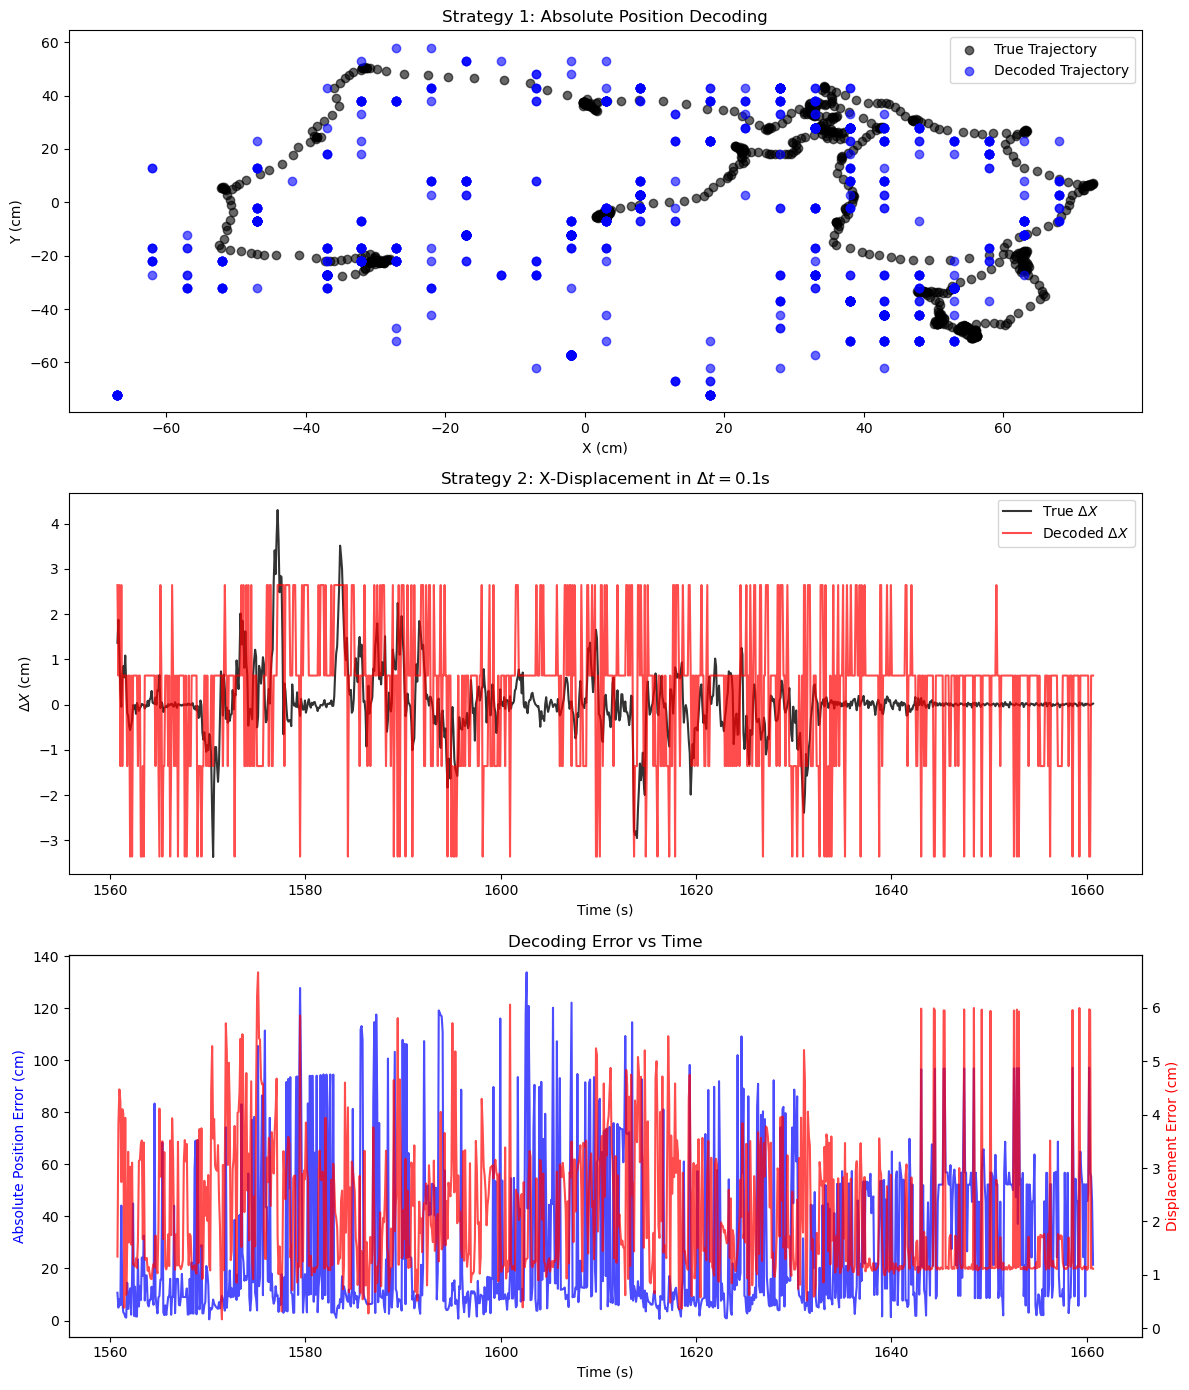

In [15]:
# ==========================================
# 5. Plotting
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# Plot 1: True vs Decoded Absolute Position Trajectory
axes[0].scatter(true_pos_x[:1000], true_pos_y[:1000], label='True Trajectory', color='black', alpha=0.6)
axes[0].scatter(dec_pos_x[:1000], dec_pos_y[:1000], label='Decoded Trajectory', color='blue', alpha=0.6)
axes[0].set_title('Strategy 1: Absolute Position Decoding')
axes[0].set_xlabel('X (cm)')
axes[0].set_ylabel('Y (cm)')
axes[0].legend()

# Plot 2: True vs Decoded Displacement over time
axes[1].plot(test_time[:1000], true_dx[:1000], label='True $\Delta X$', color='black', alpha=0.8)
axes[1].plot(test_time[:1000], dec_dx[:1000], label='Decoded $\Delta X$', color='red', alpha=0.7)
axes[1].set_title(f'Strategy 2: X-Displacement in $\Delta t = {delta_t}$s')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('$\Delta X$ (cm)')
axes[1].legend()

# Plot 3: Error for both strategies as a function of time
axes[2].plot(test_time[:1000], pos_error[:1000], label='Position Error (cm)', color='blue', alpha=0.7)
# Note: Displacement error is usually much smaller in magnitude, so plotting on a secondary axis helps visualization
ax2_twin = axes[2].twinx()
ax2_twin.plot(test_time[:1000], disp_error[:1000], label='Displacement Error (cm)', color='red', alpha=0.7)

axes[2].set_title('Decoding Error vs Time')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Absolute Position Error (cm)', color='blue')
ax2_twin.set_ylabel('Displacement Error (cm)', color='red')

fig.tight_layout()
plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_10514/3989495198.py:15: SyntaxWarning: invalid escape sequence '\D'
  axes[1].plot(test_time[-1000:], true_dx[-1000:], label='True $\Delta X$', color='black', alpha=0.8)
/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_10514/3989495198.py:16: SyntaxWarning: invalid escape sequence '\D'
  axes[1].plot(test_time[-1000:], dec_dx[-1000:], label='Decoded $\Delta X$', color='red', alpha=0.7)
/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_10514/3989495198.py:17: SyntaxWarning: invalid escape sequence '\D'
  axes[

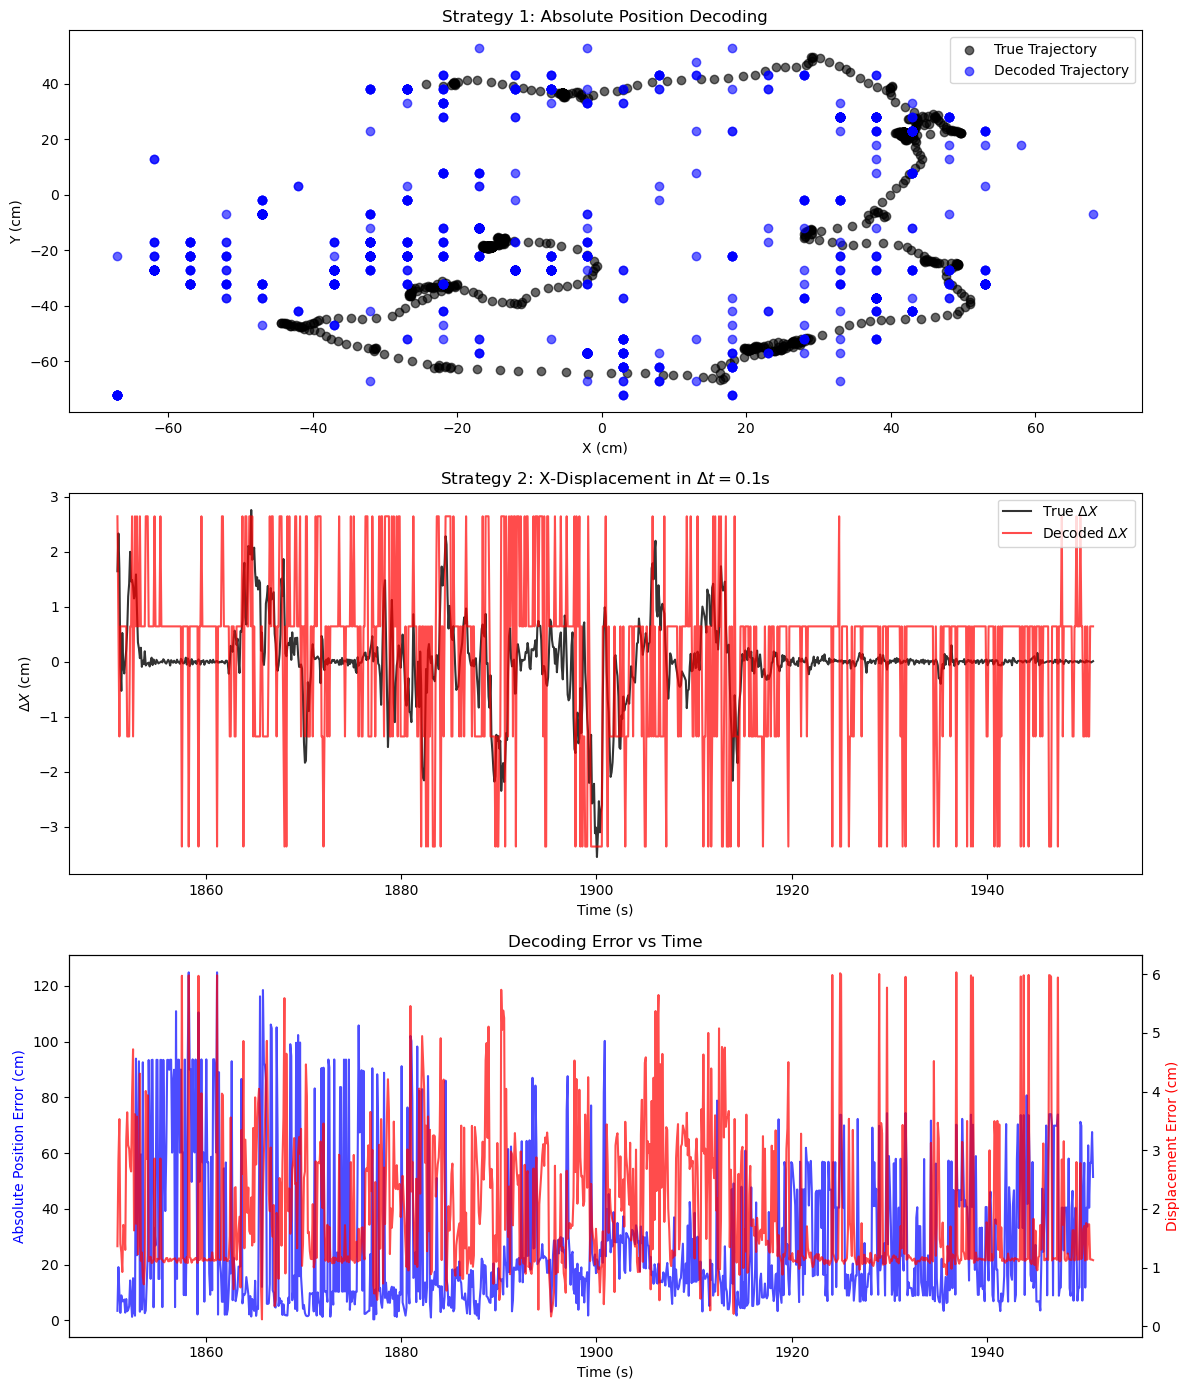

In [16]:
# ==========================================
# 5. Plotting
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# Plot 1: True vs Decoded Absolute Position Trajectory
axes[0].scatter(true_pos_x[-1000:], true_pos_y[-1000:], label='True Trajectory', color='black', alpha=0.6)
axes[0].scatter(dec_pos_x[-1000:], dec_pos_y[-1000:], label='Decoded Trajectory', color='blue', alpha=0.6)
axes[0].set_title('Strategy 1: Absolute Position Decoding')
axes[0].set_xlabel('X (cm)')
axes[0].set_ylabel('Y (cm)')
axes[0].legend()

# Plot 2: True vs Decoded Displacement over time
axes[1].plot(test_time[-1000:], true_dx[-1000:], label='True $\Delta X$', color='black', alpha=0.8)
axes[1].plot(test_time[-1000:], dec_dx[-1000:], label='Decoded $\Delta X$', color='red', alpha=0.7)
axes[1].set_title(f'Strategy 2: X-Displacement in $\Delta t = {delta_t}$s')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('$\Delta X$ (cm)')
axes[1].legend()

# Plot 3: Error for both strategies as a function of time
axes[2].plot(test_time[-1000:], pos_error[-1000:], label='Position Error (cm)', color='blue', alpha=0.7)
# Note: Displacement error is usually much smaller in magnitude, so plotting on a secondary axis helps visualization
ax2_twin = axes[2].twinx()
ax2_twin.plot(test_time[-1000:], disp_error[-1000:], label='Displacement Error (cm)', color='red', alpha=0.7)

axes[2].set_title('Decoding Error vs Time')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Absolute Position Error (cm)', color='blue')
ax2_twin.set_ylabel('Displacement Error (cm)', color='red')

fig.tight_layout()
plt.show()

In [18]:
# ==========================================
# 1. Split Data Exactly in Half
# ==========================================
split_idx = int(n_bins * 0.5)

# Half 1 Data
spikes_H1 = spike_counts[:split_idx, :]
x_H1, y_H1 = x_binned[:split_idx], y_binned[:split_idx]
time_H1 = t_centers[:split_idx]

# Half 2 Data
spikes_H2 = spike_counts[split_idx:, :]
x_H2, y_H2 = x_binned[split_idx:], y_binned[split_idx:]
time_H2 = t_centers[split_idx:]

# ==========================================
# 2. Fold 1: Train Half 1, Decode Half 2
# ==========================================
# Train
ratemaps_H1, x_edges, y_edges = build_ratemap(
    x_H1, y_H1, spikes_H1, spatial_bin_size
)

# Decode
dec_x_H2, dec_y_H2 = bayesian_decode(spikes_H2, ratemaps_H1, x_edges, y_edges)

# Calculate Error for Fold 1
error_fold1 = np.sqrt((dec_x_H2 - x_H2)**2 + (dec_y_H2 - y_H2)**2)

# ==========================================
# 3. Fold 2: Train Half 2, Decode Half 1
# ==========================================
# Train
ratemaps_H2, _, _ = build_ratemap(
    x_H2, y_H2, spikes_H2, spatial_bin_size
)

# Decode
dec_x_H1, dec_y_H1 = bayesian_decode(spikes_H1, ratemaps_H2, x_edges, y_edges)

# Calculate Error for Fold 2
error_fold2 = np.sqrt((dec_x_H1 - x_H1)**2 + (dec_y_H1 - y_H1)**2)

# ==========================================
# 4. Compare Results
# ==========================================
print(f"Mean Error (Train H1 -> Decode H2): {np.nanmean(error_fold1):.2f} cm")
print(f"Mean Error (Train H2 -> Decode H1): {np.nanmean(error_fold2):.2f} cm")

Mean Error (Train H1 -> Decode H2): 39.83 cm
Mean Error (Train H2 -> Decode H1): 34.82 cm


In [20]:
# ==========================================
# 1. Interpolate Velocity and Create Speed Mask
# ==========================================
# Interpolate velocity to match the time bins
v_binned = np.interp(t_centers, t, v)

# Create a boolean mask where True means the rat is moving at or above 3 cm/s
speed_threshold = 3.0
speed_mask = v_binned >= speed_threshold

# Apply the mask to filter out immobility data
t_valid = t_centers[speed_mask]
x_valid = x_binned[speed_mask]
y_valid = y_binned[speed_mask]
spikes_valid = spike_counts[speed_mask, :]

# ==========================================
# 2. Split Filtered Data into Chronological Halves
# ==========================================
# We want to split the session exactly in half based on time, 
# not just the number of valid bins.
session_midpoint = time_bins[int(n_bins * 0.5)]

# Half 1 (First half of the session, only moving > 3 cm/s)
h1_mask = t_valid < session_midpoint
spikes_H1 = spikes_valid[h1_mask]
x_H1 = x_valid[h1_mask]
y_H1 = y_valid[h1_mask]

# Half 2 (Second half of the session, only moving > 3 cm/s)
h2_mask = t_valid >= session_midpoint
spikes_H2 = spikes_valid[h2_mask]
x_H2 = x_valid[h2_mask]
y_H2 = y_valid[h2_mask]

# ==========================================
# 3. Fold 1: Train Half 1, Decode Half 2
# ==========================================
# Train (Build ratemaps only on active exploration in H1)
ratemaps_H1, x_edges, y_edges = build_ratemap(
    x_H1, y_H1, spikes_H1, spatial_bin_size
)

# Decode (Predict position only during active movement in H2)
dec_x_H2, dec_y_H2 = bayesian_decode(spikes_H2, ratemaps_H1, x_edges, y_edges)

# Calculate Error for Fold 1
error_fold1 = np.sqrt((dec_x_H2 - x_H2)**2 + (dec_y_H2 - y_H2)**2)

# ==========================================
# 4. Fold 2: Train Half 2, Decode Half 1
# ==========================================
# Train
ratemaps_H2, _, _ = build_ratemap(
    x_H2, y_H2, spikes_H2, spatial_bin_size
)

# Decode
dec_x_H1, dec_y_H1 = bayesian_decode(spikes_H1, ratemaps_H2, x_edges, y_edges)

# Calculate Error for Fold 2
error_fold2 = np.sqrt((dec_x_H1 - x_H1)**2 + (dec_y_H1 - y_H1)**2)

# ==========================================
# 5. Compare Results
# ==========================================
print(f"Total valid time bins (v >= {speed_threshold} cm/s): {len(t_valid)}")
print(f"Mean Error (Train H1 -> Decode H2): {np.nanmean(error_fold1):.2f} cm")
print(f"Mean Error (Train H2 -> Decode H1): {np.nanmean(error_fold2):.2f} cm")

Total valid time bins (v >= 3.0 cm/s): 10973
Mean Error (Train H1 -> Decode H2): 35.45 cm
Mean Error (Train H2 -> Decode H1): 28.00 cm
